# 0. Libraries

In [1]:
! pip install simplemma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 MB 13.4 MB/s eta 0:00:0000:0100:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings

# Filter out the specific UserWarnings
warnings.filterwarnings("ignore", category=UserWarning, message="A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy")
warnings.filterwarnings("ignore", category=UserWarning, message="unable to load libtensorflow_io_plugins.so")
warnings.filterwarnings("ignore", category=UserWarning, message="file system plugins are not loaded")

In [4]:
# Hugging Face library
from transformers import AutoTokenizer, TFAutoModel

In [5]:
# Hugging Face library
from datasets import Dataset, DatasetDict

In [6]:
import re
import nltk
import simplemma
import spacy

from simplemma import text_lemmatizer
from nltk.corpus import stopwords

# 1. Load Datasets

In [7]:
# Create a function to import the data from csv format
def load_data(file_path):
    return pd.read_csv(file_path, header=None, delimiter='\t', names=['sentiment', 'text'])


train_path = '/kaggle/input/sentiment/train_bal_vdg_27_11.tsv'
test_path = '/kaggle/input/sentiment/test_bal_vdg_27_11.tsv'
val_path = '/kaggle/input/sentiment/valid_bal_vdg_27_11.tsv'

df_train = load_data(train_path)
df_test = load_data(test_path)
df_val = load_data(val_path)

In [8]:
# To get an idea of the data
pd.set_option('display.max_colwidth', 150)
df_train.head()

,sentiment,text
0,NEU,"La lotta contro il bodyshaming è una cosa, promuovere l’obesità è un’altra"
1,POS,"La marginalità è un luogo radicale di possibilità, uno spazio di #resistenza. Ne parla @Racheleborghi in questo podcast pubblicato da #TRANSfemmIN..."
2,NEU,"@ilgiomba @GiovannaSerra3 @voilaloves @ArthurMeurs @LuniVale @antrichelieu @diegodemme4 @fabyo255 Io spero solo,che in cuor suo,Giovanna abbia ca..."
3,POS,Seppellire l'odio sotto una montagna di amore #ProudBoys 🧡💜💙💚♥️
4,NEU,#iorestoacasama non dimentico. E SE IO LOTTO DA PARTIGIANA Raccolta delle biografie delle partigiane a cura di @NonUnaDiMenoMI https://t.co/KUlwqE...


In [9]:
# Remove user mention here. could not do it in the preprocess function
df_train['text'] = df_train['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_val['text'] = df_val['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_test['text'] = df_test['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)

In [10]:
# I'm combining the pandas dataframe to the dataset dictionary of Hugging Face

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)
val_dataset = Dataset.from_pandas(df_val)

# Create the DatasetDict
dataset = DatasetDict({'train': train_dataset, 'test': test_dataset, 'validation': val_dataset})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 717
    })
    test: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 216
    })
    validation: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 92
    })
})


## 1.5 Check Duplicates

In [11]:
# Initialize a dictionary to store updated datasets
updated_datasets = {}

# Check for and remove duplicates in each split
for split in dataset.keys():
    split_data = dataset[split]
    
    # Access the 'text' column within the list
    text_column = split_data['text']
    
    # Initialize a set to track unique texts
    unique_texts = set()
    
    # Initialize lists to store the filtered data
    filtered_text = []
    
    # Iterate through the 'text' column and filter duplicates
    for text in text_column:
        if text not in unique_texts:
            unique_texts.add(text)
            filtered_text.append(text)
    
    # Create a new Dataset object with the filtered data
    updated_datasets[split] = split_data.select(list(range(len(filtered_text))))
    
    # Print the number of removed duplicates
    duplicate_count = len(text_column) - len(filtered_text)
    print(f"Duplicates removed in {split} split: {duplicate_count}\n")

# Update the dataset dictionary with the filtered datasets
dataset.update(updated_datasets)

# Print the updated dataset information
for split in dataset.keys():
    split_data = dataset[split]
    print(f"{split}: {len(split_data['text'])} rows")

print(dataset)

Duplicates removed in train split: 2

Duplicates removed in test split: 0

Duplicates removed in validation split: 1

train: 715 rows
test: 216 rows
validation: 91 rows
DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 715
    })
    test: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 216
    })
    validation: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 91
    })
})


# 2. Sentiment Distribution

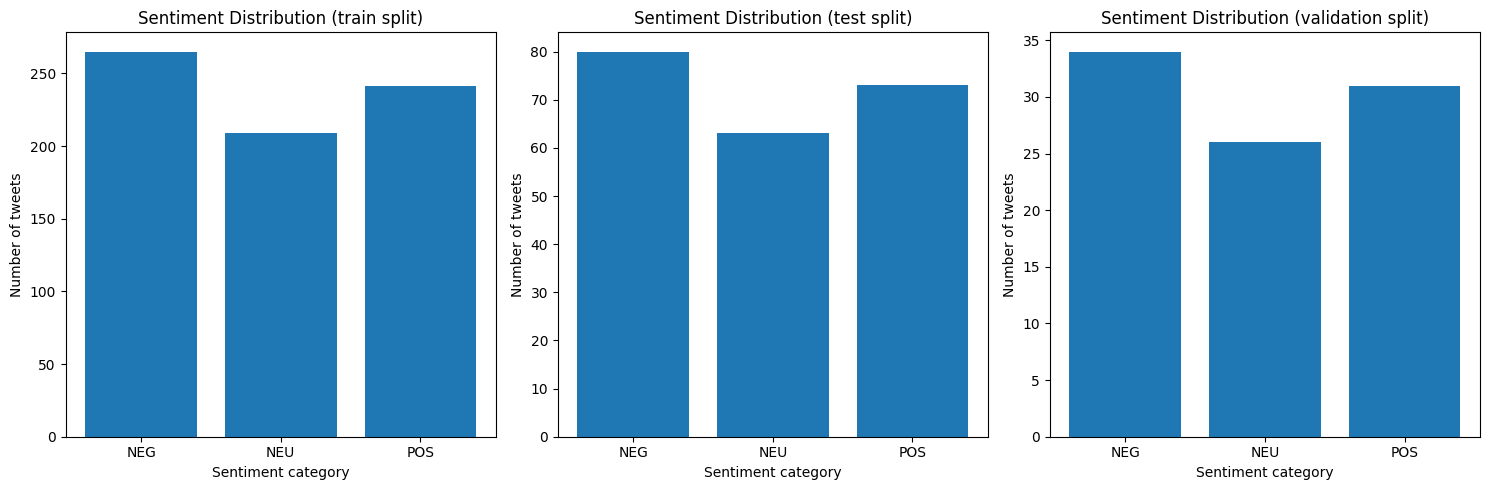

In [12]:
from collections import Counter

# Initialize dictionaries to store sentiment counts and categories for each split
sentiment_counts = {}
sentiment_categories = {}

# Loop through each split
for split in dataset.keys():
    split_data = dataset[split]
    
    # Extract sentiment data from the 'sentiment' column within the list
    sentiment_data = [item for item in split_data['sentiment']]
    
    # Calculate sentiment counts for the current split using Counter
    sentiment_count = Counter(sentiment_data)
    sentiment_counts[split] = sentiment_count
    
    # Get unique sentiment categories for the current split
    sentiment_category = list(sentiment_count.keys())
    sentiment_categories[split] = sentiment_category

# Combine all unique sentiment categories across all splits and sort them
all_sentiment_categories = sorted(set().union(*sentiment_categories.values()))

# Create subplots for each split
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Loop through each split and plot the sentiment counts
for i, split in enumerate(dataset.keys()):
    x = np.array(all_sentiment_categories)
    y = np.array([sentiment_counts[split].get(category, 0) for category in x])
    axs[i].bar(x, y)
    
    axs[i].set_title(f"Sentiment Distribution ({split} split)")
    axs[i].set_xlabel("Sentiment category")
    axs[i].set_ylabel("Number of tweets")

plt.tight_layout()
plt.show()

# 3. WordCloud

In [13]:
!python -m spacy download it_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 23.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_md')


In [14]:
import spacy

# Load the Italian language model
nlp = spacy.load("it_core_news_md")

In [ ]:
from nltk.corpus import stopwords
italian_stopwords = set(stopwords.words('italian'))

from nltk.tokenize import word_tokenize 

# Define a function to preprocess text
def preprocess_text(text):
    # Remove punctuation, URLs, and user mentions
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    
    # Process text using spaCy
    doc = nlp(text)
    
    # Filter out only nouns and lemmatize them
    lemmatized_nouns = [token.lemma_ for token in doc  if token.pos_ == 'NOUN']
    
    # Remove stopwords
    lemmatized_nouns = [word for word in lemmatized_nouns if word.lower() not in italian_stopwords]
    
    # Join the filtered and lemmatized nouns into a string
    text = ' '.join(lemmatized_nouns)
    
    return text





def preprocess_dataset(dataset):
    dataset['text'] = preprocess_text(dataset['text'])
    return dataset

dataset = dataset.map(preprocess_dataset)

In [15]:
italian_stopwords = set(stopwords.words('italian'))

# Define a function to preprocess text
def preprocess_text(text):    
    # Tokenization, lemmatization, removing punctuation, stopwords and URLs
    doc = nlp(text)
    nouns = [token.text for token in doc if token.pos_ == 'NOUN']
    
    text = ' '.join(nouns)
    
    text = text_lemmatizer(text, lang='it')
    text = ' '.join(text)
    
    text = re.sub(r'[^\w\s\']', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = ' '.join(word for word in text.split() if word.lower() not in italian_stopwords)
    

    
    return text




def preprocess_dataset(dataset):
    dataset['text'] = preprocess_text(dataset['text'])
    return dataset

dataset = dataset.map(preprocess_dataset)

  0%|          | 0/715 [00:00<?, ?ex/s]

  0%|          | 0/216 [00:00<?, ?ex/s]

  0%|          | 0/91 [00:00<?, ?ex/s]

In [16]:
from wordcloud import WordCloud

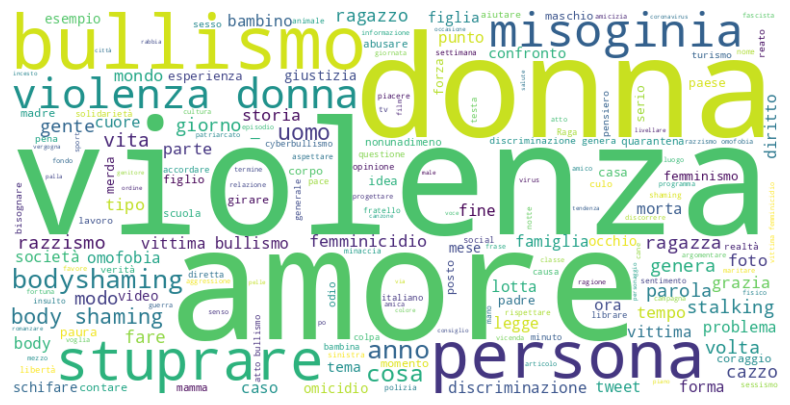

In [17]:
# Create a WordCloud object

# Combine the text from 'train', 'test', and 'validation' splits
combined_text = []

for split in ['train', 'test', 'validation']:
    combined_text.extend([text for text in dataset[split]['text']])

# Concatenate the combined text into a single string
text = ' '.join(combined_text)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Turn off axis labels
plt.show()

# 4. Checking word distribution among classes

In [18]:
# Create empty lists for each class
neg_text = []
neu_text = []
pos_text = []


for split in dataset.keys():
    for text, label in zip(dataset[split]['text'], dataset[split]['sentiment']):
        # Check the label and append the text to the corresponding list
        if label == 'NEG':
            neg_text.append(text)
        elif label == 'NEU':
            neu_text.append(text)
        elif label == 'POS':
            pos_text.append(text)

In [19]:
# All words contained in "category tweets"
negative = []
neutral = []
positive = []

# Process negative text
for sentence in neg_text:
    doc = nlp(sentence)
    nouns = [token.text for token in doc if token.pos_ == 'NOUN']
    negative.extend(nouns)

# Process neutral text
for sentence in neu_text:
    doc = nlp(sentence)
    nouns = [token.text for token in doc if token.pos_ == 'NOUN']
    neutral.extend(nouns)

# Process positive text
for sentence in pos_text:
    doc = nlp(sentence)
    nouns = [token.text for token in doc if token.pos_ == 'NOUN']
    positive.extend(nouns)


In [20]:
from nltk.probability import FreqDist


fdist_neg = FreqDist(negative)
fdist_neu = FreqDist(neutral)
fdist_pos = FreqDist(positive)

In [39]:
# Get the most common words for each category
top_words_neg = fdist_neg.most_common(1500)
top_words_neu = fdist_neu.most_common(1500)
top_words_pos = fdist_pos.most_common(1500)

# Unzip the top words and frequencies
top_words_neg, frequencies_neg = zip(*top_words_neg)
top_words_neu, frequencies_neu = zip(*top_words_neu)
top_words_pos, frequencies_pos = zip(*top_words_pos)


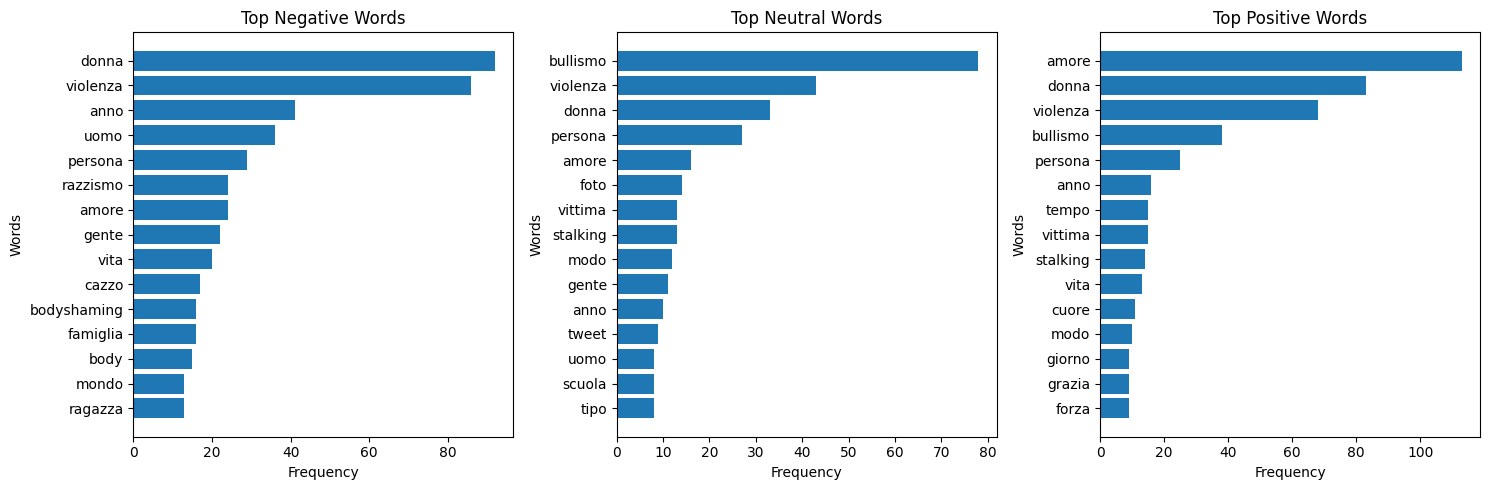

In [38]:

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot for negative words
axes[0].barh(top_words_neg, frequencies_neg)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')
axes[0].set_title('Top Negative Words')
axes[0].invert_yaxis()

# Plot for neutral words
axes[1].barh(top_words_neu, frequencies_neu)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Words')
axes[1].set_title('Top Neutral Words')
axes[1].invert_yaxis()

# Plot for positive words
axes[2].barh(top_words_pos, frequencies_pos)
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Words')
axes[2].set_title('Top Positive Words')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 5. Word Impact

In [40]:
# Calculate the total number of words in each category
total_words_in_negative = sum(frequencies_neg)
total_words_in_neutral = sum(frequencies_neu)
total_words_in_positive = sum(frequencies_pos)

# Create a dictionary to store the word impact index for each category
word_impact_index = {}

# Calculate the relative frequency of each word within its category for NEGATIVE
for word, frequency in zip(top_words_neg, frequencies_neg):
    relative_frequency = frequency / total_words_in_negative
    word_impact_index.setdefault(word, {'NEGATIVE': 0, 'NEUTRAL': 0, 'POSITIVE': 0})
    word_impact_index[word]['NEGATIVE'] = relative_frequency

# Calculate the relative frequency of each word within its category for NEUTRAL
for word, frequency in zip(top_words_neu, frequencies_neu):
    relative_frequency = frequency / total_words_in_neutral
    word_impact_index.setdefault(word, {'NEGATIVE': 0, 'NEUTRAL': 0, 'POSITIVE': 0})
    word_impact_index[word]['NEUTRAL'] = relative_frequency

# Calculate the relative frequency of each word within its category for POSITIVE
for word, frequency in zip(top_words_pos, frequencies_pos):
    relative_frequency = frequency / total_words_in_positive
    word_impact_index.setdefault(word, {'NEGATIVE': 0, 'NEUTRAL': 0, 'POSITIVE': 0})
    word_impact_index[word]['POSITIVE'] = relative_frequency


In [49]:
word_impact_index['vittima']

{'NEGATIVE': 0.00739247311827957,
 'NEUTRAL': 0.012757605495583905,
 'POSITIVE': 0.011876484560570071}